#### run this command as needed to re-establish connection to Big Query
gcloud auth login --update-adc

### Set up and getting data

In [1]:
import pandas as pd
import numpy as np
import time
from google.cloud import bigquery
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, roc_auc_score
import matplotlib.pyplot as plt
import random
import torch
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

client = bigquery.Client()

In [2]:
def lift_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    expected_positives = y_true.sum() * 0.01
    lift = actual_positives / expected_positives if expected_positives != 0 else 0
    return lift

def true_positives_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    top_indices = np.argsort(y_scores)[-top_1_percent:]
    actual_positives = y_true.iloc[top_indices].sum()
    return actual_positives

def num_samples_at_1_percent(y_true, y_scores):
    top_1_percent = max(1, int(0.01 * len(y_true)))
    return top_1_percent

def f1_score_top_1_percent(y_true, y_pred_proba):
    top_1_percent = int(0.01 * len(y_true))
    top_indices = np.argsort(y_pred_proba)[-top_1_percent:]
    y_true_top = y_true.iloc[top_indices]
    y_pred_top = np.ones(top_1_percent)
    return f1_score(y_true_top, y_pred_top)


# Make scorers
scorers = {
    'lift@1%': make_scorer(lift_at_1_percent, needs_proba=True),
    'f1@1%': make_scorer(f1_score_top_1_percent, needs_proba=True),
    'true_positives@1%': make_scorer(true_positives_at_1_percent, needs_proba=True),
    'num_samples@1%': make_scorer(num_samples_at_1_percent, needs_proba=True),
    'AUC':'roc_auc',
    'weighted AUC':make_scorer(roc_auc_score, needs_proba = True, multi_class = 'ovr', average = 'weighted') 
}

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_scorer.py:548: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


In [3]:
# Get labels (acute IP) stay (0=no, 1=yes) in the 6 months post-index date
sql = """
SELECT
    o.*
    , p.* EXCEPT(asdb_member_key, asdb_plan_key, index_dt)
FROM 
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_outcome_ip` AS o
LEFT JOIN
    `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_PQI_flag` AS p
        ON o.asdb_member_key = p.asdb_member_key
WHERE 1=1 
  AND o.asdb_member_key IN (SELECT asdb_member_key FROM `anbc-hcb-dev.cm_medicaid_hcb_dev.a534354_IP_2024_OOT_non_embedding_features` WHERE 1=1 AND NOT asdb_plan_key IN (33, 54) AND post_mnths >= 6)"""
outcome_detail = client.query(sql).to_dataframe() 
outcome_detail.shape

(1636179, 22)

In [4]:
outcome_detail.head()

,asdb_member_key,index_dt,acute_ip_flag,sum_acute_ip_admits,sum_acute_calc_los,sum_acute_admit_los,sum_acute_paid_los,sum_acute_ip_cost,pqi1,pqi3,...,pqi8,pqi11,pqi12,pqi14,pqi15,pqi5_ex,pqi7_ex,pqi11_ex,pqi12_ex,pqi15_ex
0,72478535,2023-11-01,0,0.0,0,0,0,0E-9,0,0,...,0,0,0,0,0,0,0,0,0,0
1,71327628,2023-11-01,0,0.0,0,0,0,0E-9,0,0,...,0,0,0,0,0,0,0,0,0,0
2,72032164,2023-11-01,0,0.0,0,0,0,0E-9,0,0,...,0,0,0,0,0,0,0,0,0,0
3,72222291,2023-11-01,0,0.0,0,0,0,0E-9,0,0,...,0,0,0,0,0,0,0,0,0,0
4,351690401,2023-11-01,0,0.0,0,0,0,0E-9,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
merged = pd.read_feather("OOT.feather")  

In [6]:
merged.head()

,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,med_sev_ed_visits_yr1,med_high_sev_ed_visits_yr1,high_sev_ed_visits_yr1,...,ethnicity_code_ETHN0021,ethnicity_code_ETHN0023,ethnicity_code_ETHN0025,ethnicity_code_ETHN0029,primarylanguage_desc_ARABIC,primarylanguage_desc_ENGLISH,primarylanguage_desc_No Language,primarylanguage_desc_SPANISH,primarylanguage_desc_UNKNOWN,acute_ip_flag
asdb_member_key,,,,,,,,,,,,,,,,,,,,,
450722972,1,1,0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
451333181,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
520490691,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
72031025,2,1,0,0,0,0,0,0,2,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
351519251,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [7]:
merged = merged.merge(outcome_detail, on='asdb_member_key', how='left')

In [8]:
merged.head()

,asdb_member_key,sum_ed_visits_yr1,ed_flag_yr1,sum_avoidable_yr1,sum_unnecessary_yr1,sum_preventable_yr1,low_sev_ed_visits_yr1,low_med_sev_ed_visits_yr1,med_sev_ed_visits_yr1,med_high_sev_ed_visits_yr1,...,pqi8,pqi11,pqi12,pqi14,pqi15,pqi5_ex,pqi7_ex,pqi11_ex,pqi12_ex,pqi15_ex
0,450722972,1,1,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,451333181,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,520490691,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,72031025,2,1,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
4,351519251,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
merged.shape

(1636185, 663)

In [43]:
merged['pqi5_f'] = np.where((merged['pqi5'] == 1) & (merged['pqi5_ex'] == 0 ), 1, 0)
merged['pqi7_f'] = np.where((merged['pqi7'] == 1) & (merged['pqi7_ex'] == 0 ), 1, 0)
merged['pqi11_f'] = np.where((merged['pqi11'] == 1) & (merged['pqi11_ex'] == 0 ), 1, 0)
merged['pqi12_f'] = np.where((merged['pqi12'] == 1) & (merged['pqi12_ex'] == 0 ), 1, 0)
merged['pqi15_f'] = np.where((merged['pqi15'] == 1) & (merged['pqi15_ex'] == 0 ), 1, 0)

In [11]:
def check_label_distribution(y):
    # Count the number of occurrences of each label 
    count_0 = (y == 0).sum()
    count_1 = (y == 1).sum()
    ratio = count_1 / count_0 if count_0 != 0 else np.inf
    print(count_0, count_1, ratio)
    return count_0, count_1, ratio

print("\nTest Set:")
check_label_distribution(merged.loc[:, 'acute_ip_flag_x'])


Test Set:
1609769 26416 0.016409807866843006


(1609769, 26416, 0.016409807866843006)

In [12]:
outcome_detail['pqi1'].value_counts()

pqi1
0    1635556
1        623
Name: count, dtype: Int64

In [13]:
outcome_detail['pqi3'].value_counts()

pqi3
0    1635620
1        559
Name: count, dtype: Int64

In [14]:
outcome_detail['pqi5'].value_counts()

pqi5
0    1635271
1        908
Name: count, dtype: Int64

In [15]:
outcome_detail['pqi7'].value_counts()

pqi7
0    1635902
1        277
Name: count, dtype: Int64

In [16]:
outcome_detail['pqi8'].value_counts()

pqi8
0    1634989
1       1190
Name: count, dtype: Int64

In [17]:
outcome_detail['pqi11'].value_counts()

pqi11
0    1635318
1        861
Name: count, dtype: Int64

In [18]:
outcome_detail['pqi12'].value_counts()

pqi12
0    1635667
1        512
Name: count, dtype: Int64

In [19]:
outcome_detail['pqi14'].value_counts()

pqi14
0    1636035
1        144
Name: count, dtype: Int64

In [20]:
outcome_detail['pqi15'].value_counts()

pqi15
0    1635743
1        436
Name: count, dtype: Int64

In [21]:
pd.crosstab(outcome_detail['acute_ip_flag'], outcome_detail['pqi1'], dropna=False)

pqi1,0,1
acute_ip_flag,,
0,1609758,10
1,25798,613


In [22]:
pd.crosstab(outcome_detail['acute_ip_flag'], outcome_detail['pqi3'], dropna=False)

pqi3,0,1
acute_ip_flag,,
0,1609759,9
1,25861,550


In [23]:
pd.crosstab(outcome_detail['acute_ip_flag'], outcome_detail['pqi5'], dropna=False)

pqi5,0,1
acute_ip_flag,,
0,1609753,15
1,25518,893


In [24]:
pd.crosstab(outcome_detail['pqi5'], outcome_detail['pqi5_ex'], dropna=False)

pqi5_ex,0,1
pqi5,,
0,1633052,2219
1,905,3


In [25]:
pd.crosstab(outcome_detail['pqi7'], outcome_detail['pqi7_ex'], dropna=False)

pqi7_ex,0,1
pqi7,,
0,1631010,4892
1,248,29


In [26]:
pd.crosstab(outcome_detail['pqi11'], outcome_detail['pqi11_ex'], dropna=False)

pqi11_ex,0,1
pqi11,,
0,1634322,996
1,858,3


In [27]:
pd.crosstab(outcome_detail['pqi12'], outcome_detail['pqi12_ex'], dropna=False)

pqi12_ex,0,1
pqi12,,
0,1632191,3476
1,492,20


In [28]:
pd.crosstab(outcome_detail['pqi15'], outcome_detail['pqi15_ex'], dropna=False)

pqi15_ex,0,1
pqi15,,
0,1633523,2220
1,434,2


In [31]:
import xgboost as xgb
model = xgb.XGBClassifier()
model.load_model("mdcd_ip_2024_final_model.cbm")

In [32]:
model

XGBClassifier(base_score='1.3198793E-1', booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None,
              feature_types=['int', 'int', 'int', 'float', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int', 'int', 'int',
                             'int', 'int', 'int', 'int', 'int'...
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [33]:
import pandas as pd
# Get the selected features from RFE

f = open('xgboost_selected_features.txt', 'r')
selected_features = [x.strip() for x in f.readlines()]
print(len(selected_features))
f.close()

merged = merged[merged['acute_ip_flag_x'].notna()]

X_test_df = pd.DataFrame(merged, columns = merged.columns)
X_test = X_test_df[selected_features]

# X_test

78


In [34]:
y_test = merged['pqi1']

#### Metrics for Optimal Model

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = y_test.reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(y_test, y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8751351951096616
1% Lift:  34.34991974317817
1% PPV:  1.3079885092598251
1% Sensitivity:  34.34991974317817
10% Lift:  6.789727126805778
10% PPV:  0.25852901270031414
10% Sensitivity:  67.89727126805778


Text(0.5, 427.9555555555555, 'Predicted label')

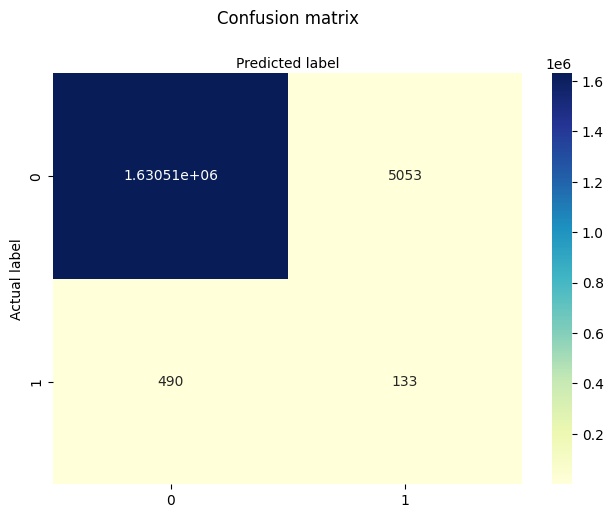

In [36]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [37]:
y_test = merged['pqi3']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)

In [39]:
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.9646759499391486
1% Lift:  44.18604651162791
1% PPV:  1.5096876719026955
1% Sensitivity:  44.18604651162791
10% Lift:  9.033989266547405
10% PPV:  0.3086457480228337
10% Sensitivity:  90.33989266547407


Text(0.5, 427.9555555555555, 'Predicted label')

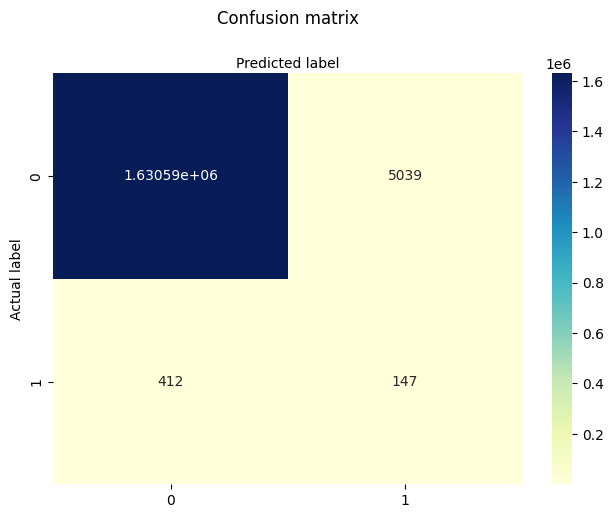

In [38]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [44]:
y_test = merged['pqi5_f']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8677927918674987
1% Lift:  27.18232044198895
1% PPV:  1.5035755760650327
1% Sensitivity:  27.18232044198895
10% Lift:  6.8397790055248615
10% PPV:  0.3783202337151169
10% Sensitivity:  68.39779005524862


Text(0.5, 427.9555555555555, 'Predicted label')

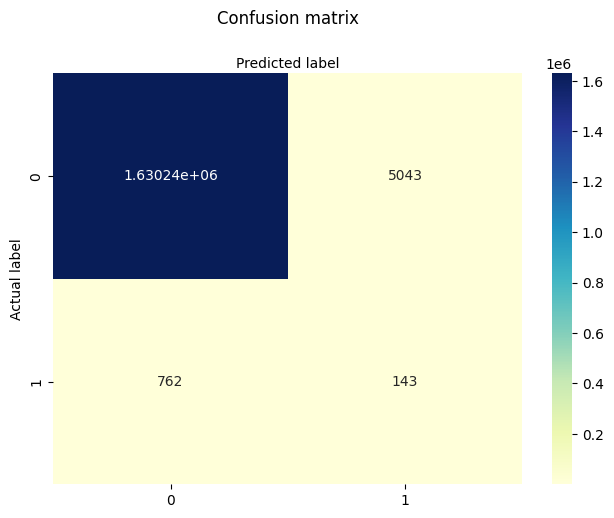

In [45]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [46]:
y_test = merged['pqi7_f']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.896047537627987
1% Lift:  27.419354838709676
1% PPV:  0.41562251696106595
1% Sensitivity:  27.419354838709676
10% Lift:  6.370967741935484
10% PPV:  0.09656639245070836
10% Sensitivity:  63.70967741935484


Text(0.5, 427.9555555555555, 'Predicted label')

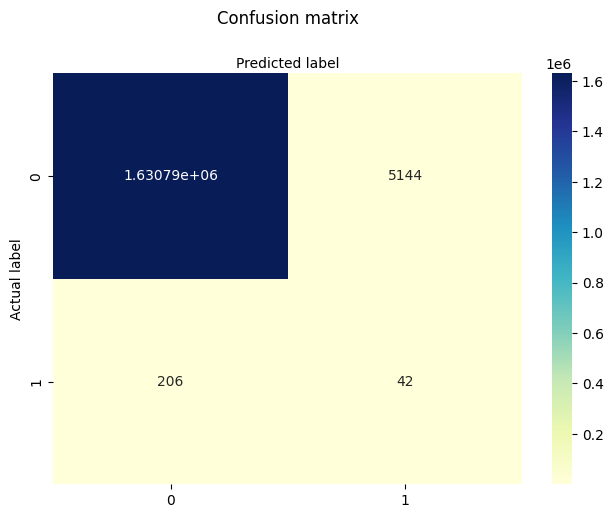

In [47]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [48]:
y_test = merged['pqi8']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.9578031814195408
1% Lift:  47.14285714285714
1% PPV:  3.4288857649287943
1% Sensitivity:  47.14285714285714
10% Lift:  8.714285714285714
10% PPV:  0.6337933479201555
10% Sensitivity:  87.14285714285714


Text(0.5, 427.9555555555555, 'Predicted label')

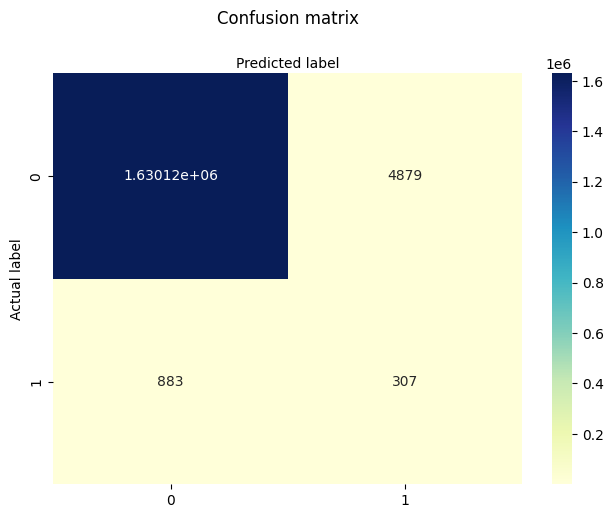

In [49]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [50]:
y_test = merged['pqi11_f']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.873405270543733
1% Lift:  28.554778554778554
1% PPV:  1.4974634802273699
1% Sensitivity:  28.554778554778554
10% Lift:  6.84149184149184
10% PPV:  0.3587624833453532
10% Sensitivity:  68.41491841491842


Text(0.5, 427.9555555555555, 'Predicted label')

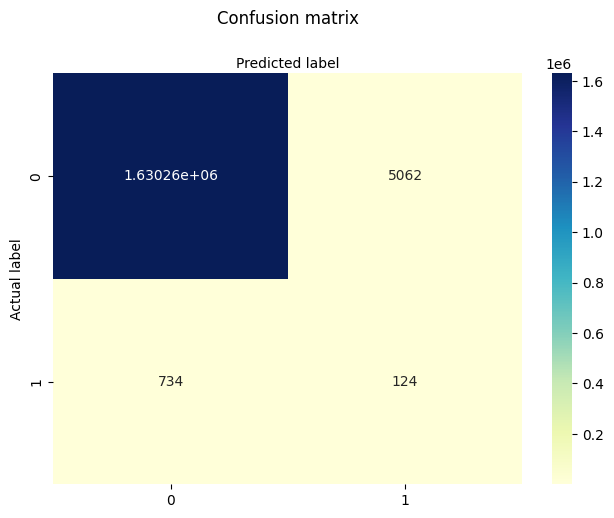

In [51]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [52]:
y_test = merged['pqi12_f']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.9062488917516519
1% Lift:  33.333333333333336
1% PPV:  1.0023837173766885
1% Sensitivity:  33.33333333333333
10% Lift:  7.5406504065040645
10% PPV:  0.22674766834944812
10% Sensitivity:  75.40650406504065


Text(0.5, 427.9555555555555, 'Predicted label')

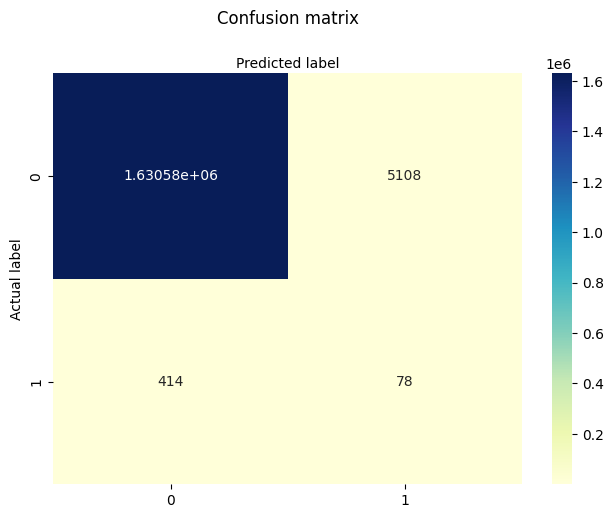

In [53]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [54]:
y_test = merged['pqi14']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.8808312834152691
1% Lift:  35.41666666666667
1% PPV:  0.3117168877207995
1% Sensitivity:  35.41666666666667
10% Lift:  7.083333333333333
10% PPV:  0.06234032930362185
10% Sensitivity:  70.83333333333334


Text(0.5, 427.9555555555555, 'Predicted label')

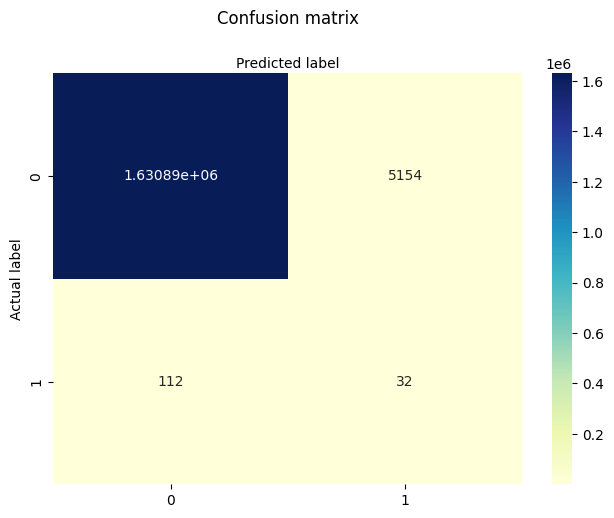

In [55]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [56]:
y_test = merged['pqi15_f']
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

ROC:  0.7643554497256853
1% Lift:  10.368663594470046
1% PPV:  0.27504431269482305
1% Sensitivity:  10.368663594470046
10% Lift:  4.562211981566819
10% PPV:  0.121013580412913
10% Sensitivity:  45.622119815668206


Text(0.5, 427.9555555555555, 'Predicted label')

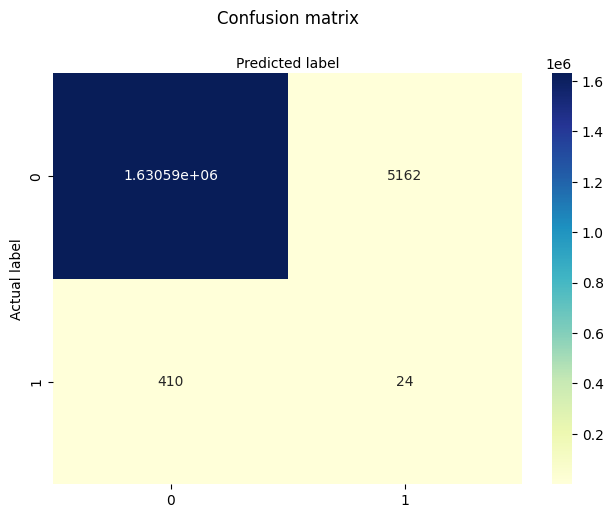

In [57]:
y_pred_test_class = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(y_test, y_pred_test_class, target_names=target_names))
#10.6% Recall/sensitivity; 53.9% PPV

In [ ]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(y_test, y_pred_test, step=0.01)


In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, y_test, name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [ ]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

#impactable subset

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def calculate_metrics(model):
    # Probabilities of the positive class
    y_pred_test = model.predict_proba(X_test)[:, 1]

    # Resetting the index of y_test for alignment
    y_test_reset = merged['impactable'].reset_index(drop=True)

    # ROC AUC Score
    roc_auc_test = roc_auc_score(merged['impactable'], y_pred_test)

    # Sorting indices by predicted probabilities in descending order
    idx = np.argsort(y_pred_test)[::-1]

    # Function to calculate metrics for a given cutoff percentile
    def calculate_percentile_metrics(y_test_reset, idx, percentile):
        cutoff = int(percentile * len(y_test_reset))  # Number of data points in the top percentile
        top_indices = idx[:cutoff]  # Indices of the top percentile predictions

        # Binary predictions for the top percentile
        predictions_binary = np.zeros(len(y_test_reset), dtype=int)
        predictions_binary[top_indices] = 1

        # Confusion matrix calculation
        tn, fp, fn, tp = confusion_matrix(y_test_reset, predictions_binary, labels=[0, 1]).ravel()

        # Performance metrics
        ppv = 100 * (tp / (tp + fp)) if (tp + fp) > 0 else 0  # Positive Predictive Value
        sensitivity = 100 * (tp / (tp + fn)) if (tp + fn) > 0 else 0  # Sensitivity or Recall

        # Lift calculation
        actual_positives_top_perc = y_test_reset[top_indices].sum()
        expected_positives = y_test_reset.sum() * percentile
        lift = actual_positives_top_perc / expected_positives if expected_positives > 0 else 0

        return lift, ppv, sensitivity

    lift_1_perc, ppv_1_perc, sensitivity_1_perc = calculate_percentile_metrics(y_test_reset, idx, 0.01)
    lift_10_perc, ppv_10_perc, sensitivity_10_perc = calculate_percentile_metrics(y_test_reset, idx, 0.10)

    return roc_auc_test, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc
roc, lift_1_perc, lift_10_perc, ppv_1_perc, sensitivity_1_perc, ppv_10_perc, sensitivity_10_perc = calculate_metrics(model)
print("ROC: ",roc)
print("1% Lift: ",lift_1_perc)
print("1% PPV: ",ppv_1_perc)
print("1% Sensitivity: ",sensitivity_1_perc)
print("10% Lift: ",lift_10_perc)
print("10% PPV: ",ppv_10_perc)
print("10% Sensitivity: ",sensitivity_10_perc)

In [ ]:
# Other metrics
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt


y_pred_test_class = model.predict(X_test)

# # Uncomment for applying threshold, can always tune after model run
# threshold = 0.25
# y_pred_test_class = (y_pred_test >= threshold).astype(int)

cm = confusion_matrix(merged['impactable'], y_pred_test_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
#11.8% Recall/Sensitivity; 38.3% PPV

In [ ]:
from sklearn.metrics import classification_report
target_names = ['without IP', 'with IP']
print(classification_report(merged['impactable'], y_pred_test_class, target_names=target_names))

In [ ]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()
y_pred_test = model.predict_proba(X_test)[:, 1]
plot_lift_curve(merged['impactable'], y_pred_test, step=0.01)

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
    model, X_test, merged['impactable'], name="KMDO_logreg", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

In [ ]:
from sklearn.metrics import auc, average_precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, make_scorer, precision_recall_curve, PrecisionRecallDisplay, roc_auc_score

precision, recall, thresholds = precision_recall_curve(merged['impactable'], y_pred_test)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

In [ ]:
### PASTED OVER FROM GITHUB
def lift_chart(X,actual_target,model):
    avg_tgt = actual_target.sum()/len(actual_target)
    df_data = X.copy()
    X_data = df_data.copy()
    df_data['Actual'] = actual_target
    df_data['Predict']= model.predict(X_data)
    y_Prob = pd.DataFrame(model.predict_proba(X_data))
    df_data['Prob_1']=list(y_Prob[1])
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Percentile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Percentile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(actual_target))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df
lift_chart= lift_chart(X_test, merged['impactable'], model)
lift_chart

In [ ]:
lift_chart.to_csv('impactable_lift_chart_xgboost.csv')

In [ ]:
def plot_lift_curve(y_val, y_pred, step=0.01):
    
    #Define an auxiliar dataframe to plot the curve
    aux_lift = pd.DataFrame()
    #Create a real and predicted column for our new DataFrame and assign values
    aux_lift['real'] = y_val
    aux_lift['predicted'] = y_pred
    #Order the values for the predicted probability column:
    aux_lift.sort_values('predicted',ascending=False,inplace=True)
    
    #Create the values that will go into the X axis of our plot
    x_val = np.arange(step,1+step,step)
    #Calculate the ratio of ones in our data
    ratio_ones = aux_lift['real'].sum() / len(aux_lift)
    #Create an empty vector with the values that will go on the Y axis our our plot
    y_v = []
    
    #Calculate for each x value its correspondent y value
    for x in x_val:
        num_data = int(np.ceil(x*len(aux_lift))) #The ceil function returns the closest integer bigger than our number 
        data_here = aux_lift.iloc[:num_data,:]   # ie. np.ceil(1.4) = 2
        ratio_ones_here = data_here['real'].sum()/len(data_here)
        y_v.append(ratio_ones_here / ratio_ones)
           
   #Plot the figure
    fig, axis = plt.subplots()
    fig.figsize = (40,40)
    axis.plot(x_val, y_v, 'g-', linewidth = 3, markersize = 5)
    axis.plot(x_val, np.ones(len(x_val)), 'k-')
    axis.set_xlabel('Proportion of sample')
    axis.set_ylabel('Lift')
    plt.title('Lift Curve')
    plt.show()

In [ ]:
merged['y_pred'] = model.predict(X_test)

In [ ]:
merged['y_prob'] = model.predict_proba(X_test)[:, 1]

In [ ]:
threshold = 0.3

merged['y_predict_class'] = ((model.predict_proba(X_test)[:, 1])>= threshold).astype(int)

In [ ]:
y_pred = merged[['y_pred', 'y_prob', 'y_predict_class', 'impactable']]
y_pred

y_pred.head()
#y_id = y_train.iloc[0]
pd.crosstab(y_pred['impactable'], y_pred['y_predict_class'])

In [ ]:
y_pred.head()

In [ ]:
m0_3 = merged.loc[merged['tenure_yr1'].isin([0,1,2,3,])]
m4_8 = merged.loc[merged['tenure_yr1'].isin([4,5,6,7,8,])]
m_9_13 = merged.loc[merged['tenure_yr1'].isin([9,10,11,12,13,])]

In [ ]:
Foster = merged[merged['coa_population_category_Foster'] == 1]

ABD = merged[(merged['coa_population_category_DD'] == 1) | 
             (merged['coa_population_category_ABD Non Dual Non LTSS'] == 1)]

LTSS = merged[(merged['coa_population_category_ABD Non Dual LTSS'] == 1) | 
              (merged['coa_population_category_Dual Elig LTSS'] == 1) |
              (merged['coa_population_category_Dual Int LTSS'] == 1) |
              (merged['coa_population_category_LTSS Only'] == 1) ]

Dual = merged[(merged['coa_population_category_Dual Elig NonLTSS'] == 1) | 
             (merged['coa_population_category_Dual Int NonLTSS'] == 1)]

BH = merged[(merged['coa_population_category_BH Int SMI'] == 1)]

Adult = merged[(merged['coa_population_category_Expansion'] == 1) | 
             ((merged['coa_population_category_TANF'] == 1) & (merged['agenbr'] >= 18)) |
             ((merged['coa_population_category_CHIP'] == 1) & (merged['agenbr'] >= 18))]

Kid = merged[((merged['coa_population_category_TANF'] == 1) & (merged['agenbr'] < 18)) | 
             ((merged['coa_population_category_CHIP'] == 1) & (merged['agenbr'] < 18)) ]

In [ ]:
plot_lift_curve(Foster['impactable'], Foster['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(LTSS['impactable'], LTSS['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Dual['impactable'], Dual['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(BH['impactable'], BH['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Adult['impactable'], Adult['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(Kid['impactable'], Kid['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m0_3['impactable'], m0_3['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m4_8['impactable'], m4_8['y_predict_class'], step=0.01)

In [ ]:
plot_lift_curve(m_9_13['impactable'], m_9_13['y_predict_class'], step=0.01)

In [ ]:
def lift_chart(df):
    avg_tgt = df['impactable']/len(df['impactable'])
    df_data = df.copy()
    df_data['Actual'] = df['impactable']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,10,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['impactable']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df   

In [ ]:
#lift_chart(merged[merged['tenure_yr1'].isin([0,1,2,3])])
lift_chart(m0_3)

In [ ]:
#lift_chart(df_out[df_out['tenure_yr1'].isin([4,5,6,7,8])])
lift_chart(m4_8)

In [ ]:
#lift_chart(df_out[df_out['tenure_yr1'].isin([9,10,11,12,13])])
lift_chart(m_9_13)

In [ ]:
lift_chart(Foster)

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)

In [ ]:
def lift_chart(df):
    avg_tgt = df['impactable']/len(df['impactable'])
    df_data = df.copy()
    df_data['Actual'] = df['impactable']
    df_data['Predict'] = df['y_predict_class']
    df_data['Prob_1'] = df['y_prob']
    df_data.sort_values(by=['Prob_1'],ascending=False,inplace=True)
    df_data.reset_index(drop=True,inplace=True)
    df_data['Decile']=pd.qcut(df_data.index,100,labels=False)
    output_df = pd.DataFrame()
    grouped = df_data.groupby('Decile',as_index=False)
    output_df['Max_Scr']=grouped.max().Prob_1
    output_df['Min_Scr']=grouped.min().Prob_1
    output_df['Actual']=grouped.sum().Actual
    output_df['Total']=grouped.count().Actual
    output_df["Population_perc"] = (output_df["Total"]/len(df['impactable']))*100
    output_df['Per_Events'] = (output_df['Actual']/output_df['Actual'].sum())*100
    output_df['Gain_Percentage'] = output_df.Per_Events.cumsum()
    output_df["Cumulative_Population"] = output_df.Population_perc.cumsum()
    output_df["Lift"] = output_df["Gain_Percentage"]/output_df["Cumulative_Population"]
    return output_df  
#y_prob

In [ ]:
lift_chart(m0_3)

In [ ]:
lift_chart(m4_8)

In [ ]:
lift_chart(m_9_13)

In [ ]:
lift_chart(Foster) 

In [ ]:
lift_chart(ABD)

In [ ]:
lift_chart(LTSS)

In [ ]:
lift_chart(Dual)

In [ ]:
lift_chart(BH)

In [ ]:
lift_chart(Adult)

In [ ]:
lift_chart(Kid)